# AI-Assisted House Price Prediction

## Assignment 1 — Part 1

This notebook presents an end-to-end data science workflow using the
Kaggle House Prices: Advanced Regression Techniques dataset.

The workflow follows a CRISP-DM-inspired process:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Interpretation

In [11]:
print("Hello CMPE 255!")

Hello CMPE 255!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv("../data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

In [6]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)

In [9]:
missing[missing > 0].head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [10]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [11]:
print("Dataset shape:", df.shape)

print("\nData type counts:")
print(df.dtypes.value_counts())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTop missing values:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

print("\nSalePrice summary:")
print(df["SalePrice"].describe())


Dataset shape: (1460, 81)

Data type counts:
str        43
int64      35
float64     3
Name: count, dtype: int64

Duplicate rows: 0

Top missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

SalePrice summary:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


### Initial Data Understanding

The training dataset contains 1,460 observations and 81 columns.
Since `SalePrice` is the target variable, the remaining columns represent
potential features for predicting house prices.

The dataset contains a mixture of numerical and categorical variables.
This means that a single preprocessing method cannot be applied to all
features, and numerical and categorical columns will need to be handled
separately.

No duplicate rows were found in the dataset.

Several variables contain a large number of missing values. Features such
as `PoolQC`, `MiscFeature`, `Alley`, and `Fence` are missing for most
observations. However, these missing values should not automatically be
treated as data-quality errors because some may represent the absence of
a property feature, such as a house having no pool, alley access, or fence.

The median `SalePrice` is $163,000, while the 75th percentile is $214,000
and the maximum observed price is $755,000. The large difference between
the typical sale price and the maximum suggests that the target variable
may be right-skewed and may contain high-price outliers.

Further analysis of the `SalePrice` distribution is therefore needed
before modeling.

## Target Variable Analysis

Before building a regression model, I examined the distribution of
`SalePrice` to understand the range, skewness, and possible extreme values.

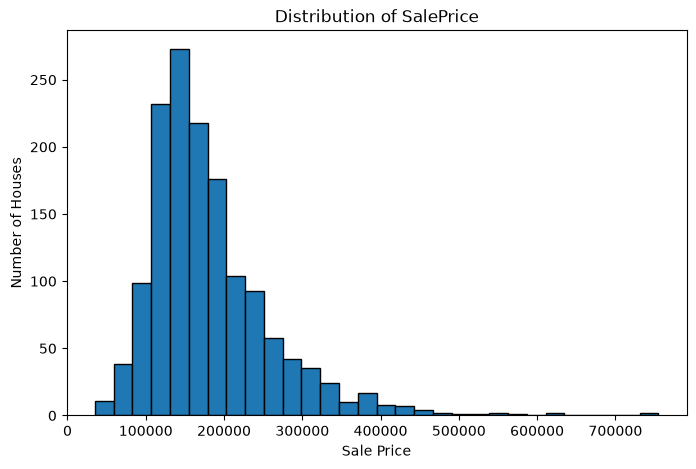

In [62]:
plt.figure(figsize=(8, 5))

plt.hist(df["SalePrice"], bins=30, edgecolor="black")

plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of SalePrice")

plt.savefig(
    "../figures/saleprice_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [14]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

### SalePrice Distribution Interpretation

The `SalePrice` distribution is strongly right-skewed.

The calculated skewness is approximately 1.88, which indicates that most
houses are concentrated in the lower and middle price ranges, while a smaller
number of expensive homes create a long right tail.

This suggests that extreme high-price observations may have a noticeable
effect on regression models and evaluation metrics such as RMSE.

A log transformation of `SalePrice` may be investigated later, but I will
first continue exploring the original target distribution and feature
relationships before deciding whether the transformation is justified.

## Missing Value Analysis

Some features contain a large number of missing values.

Before deciding how to preprocess them, I examined whether the missing values
represent unknown data or the absence of a property feature.

In [15]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "MissingCount": missing_count,
    "MissingPercent": missing_percent
})

missing_summary = missing_summary[missing_summary["MissingCount"] > 0]
missing_summary = missing_summary.sort_values(
    by="MissingPercent",
    ascending=False
)

missing_summary.head(20)

,MissingCount,MissingPercent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


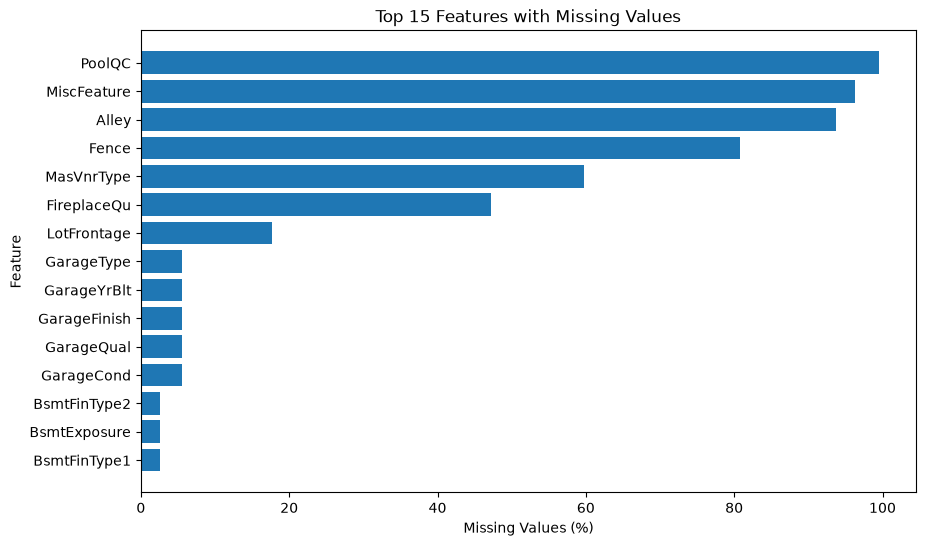

In [66]:
top_missing = missing_summary.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_missing.index[::-1],
    top_missing["MissingPercent"][::-1]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Top 15 Features with Missing Values")

plt.savefig(
    "../figures/missing_values.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [68]:
columns_to_check = [
    "PoolQC",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "BsmtQual"
]

for col in columns_to_check:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


PoolQC
PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

Alley
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Fence
Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

FireplaceQu
FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

GarageType
GarageType
Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

BsmtQual
BsmtQual
TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: count, dtype: int64


In [22]:
df.loc[df["PoolQC"].isna(), "PoolArea"].value_counts().head()

PoolArea
0    1453
Name: count, dtype: int64

In [23]:
df.loc[df["GarageType"].isna(), "GarageCars"].value_counts(dropna=False)

GarageCars
0    81
Name: count, dtype: int64

In [24]:
df.loc[df["BsmtQual"].isna(), "TotalBsmtSF"].value_counts(dropna=False)

TotalBsmtSF
0    37
Name: count, dtype: int64

### Interpretation of Structural Missing Values

The missing-value analysis suggests that some missing values represent the
absence of a property feature rather than unknown or corrupted data.

For example:

- All 1,453 houses with missing `PoolQC` have `PoolArea = 0`.
- All 81 houses with missing `GarageType` have `GarageCars = 0`.
- All 37 houses with missing `BsmtQual` have `TotalBsmtSF = 0`.

These results provide strong evidence that the missing values in these
features are structural. In other words, the value is missing because the
house does not have a pool, garage, or basement.

Therefore, these categorical missing values should not automatically be
replaced with the most common category. A category such as `"None"` or
`"NoGarage"` may preserve more meaningful information during preprocessing.

In [25]:
raw_df = pd.read_csv("../data/train.csv", keep_default_na=False)

raw_df["MasVnrType"].value_counts().head(10)

MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NA           8
Name: count, dtype: int64

In [26]:
raw_df["Alley"].value_counts().head(10)

Alley
NA      1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [27]:
raw_df["PoolQC"].value_counts().head(10)

PoolQC
NA    1453
Gd       3
Ex       2
Fa       2
Name: count, dtype: int64

### Important Finding: Domain Values vs. Missing Values

A second inspection of the raw CSV revealed an important data-loading issue.

Pandas automatically interprets strings such as `"NA"` and `"None"` as
missing values under its default CSV parsing behavior. However, in this
dataset, these strings can have domain-specific meanings.

Examples include:

- `PoolQC = "NA"` represents a house with no pool.
- `Alley = "NA"` represents no alley access.
- `MasVnrType = "None"` represents no masonry veneer.

Therefore, treating all of these values as generic missing data would remove
meaningful information.

For example, `MasVnrType` contains 864 `"None"` observations and only 8
`"NA"` observations. The default Pandas import combined these into 872
missing values.

This means missing-value handling must consider the meaning of each feature
rather than applying one global strategy.

In [29]:
from pandas.api.types import is_string_dtype

na_interpretation_effect = []

for col in raw_df.columns:
    if is_string_dtype(raw_df[col]):
        default_missing = df[col].isna().sum()
        literal_none = (raw_df[col] == "None").sum()
        literal_na = (raw_df[col] == "NA").sum()

        if default_missing > 0 or literal_none > 0 or literal_na > 0:
            na_interpretation_effect.append({
                "Feature": col,
                "PandasMissing": default_missing,
                "Literal_None": literal_none,
                "Literal_NA": literal_na
            })

na_effect_df = pd.DataFrame(na_interpretation_effect)

na_effect_df.sort_values(
    "PandasMissing",
    ascending=False
).head(30)

,Feature,PandasMissing,Literal_None,Literal_NA
16,PoolQC,1453,0,1453
18,MiscFeature,1406,0,1406
1,Alley,1369,0,1369
17,Fence,1179,0,1179
2,MasVnrType,872,864,8
10,FireplaceQu,690,0,690
0,LotFrontage,259,0,259
11,GarageType,81,0,81
12,GarageYrBlt,81,0,81
13,GarageFinish,81,0,81


### Missing-Value Parsing Finding

The raw CSV inspection revealed that Pandas' default missing-value parsing
can remove important domain information.

In particular, the default import treated both `"NA"` and `"None"` as
missing values.

For example, `MasVnrType` appeared to contain 872 missing values under the
default Pandas import. However, the raw CSV actually contains:

- 864 `"None"` values, representing houses with no masonry veneer
- 8 `"NA"` values, representing genuinely unavailable values

Similar `"NA"` values in features such as `PoolQC`, `GarageType`,
`BsmtQual`, and `FireplaceQu` represent the absence of a property feature
rather than corrupted data.

Therefore, the dataset will be loaded with the original string values
preserved, and missing values will be handled according to the meaning
of each feature.

## Domain-Aware Data Cleaning

Based on the missing-value investigation, I created a cleaned copy of the
dataset that preserves meaningful absence categories while keeping genuine
unknown values as missing data.

In [30]:
clean_df = raw_df.copy()

In [32]:
absence_mapping = {
    "PoolQC": "NoPool",
    "Alley": "NoAlley",
    "Fence": "NoFence",
    "MiscFeature": "NoMiscFeature",
    "FireplaceQu": "NoFireplace"
}

for col, label in absence_mapping.items():
    clean_df[col] = clean_df[col].replace("NA", label)

In [33]:
garage_columns = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

for col in garage_columns:
    clean_df.loc[
        (clean_df["GarageCars"] == 0) & (clean_df[col] == "NA"),
        col
    ] = "NoGarage"

In [35]:
basement_columns = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

for col in basement_columns:
    clean_df.loc[
        (clean_df["TotalBsmtSF"] == 0) & (clean_df[col] == "NA"),
        col
    ] = "NoBasement"

In [36]:
for col in basement_columns:
    clean_df[col] = clean_df[col].replace("NA", np.nan)

In [37]:
clean_df["MasVnrType"] = clean_df["MasVnrType"].replace({
    "None": "NoMasonryVeneer",
    "NA": np.nan
})

In [38]:
numeric_missing_columns = [
    "LotFrontage",
    "GarageYrBlt",
    "MasVnrArea"
]

for col in numeric_missing_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col].replace("NA", np.nan),
        errors="coerce"
    )

In [39]:
clean_df["Electrical"] = clean_df["Electrical"].replace("NA", np.nan)

In [40]:
clean_df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [41]:
numeric_df = clean_df.select_dtypes(include=["int64", "float64"])

correlations = (
    numeric_df.corr(numeric_only=True)["SalePrice"]
    .sort_values(ascending=False)
)

correlations.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

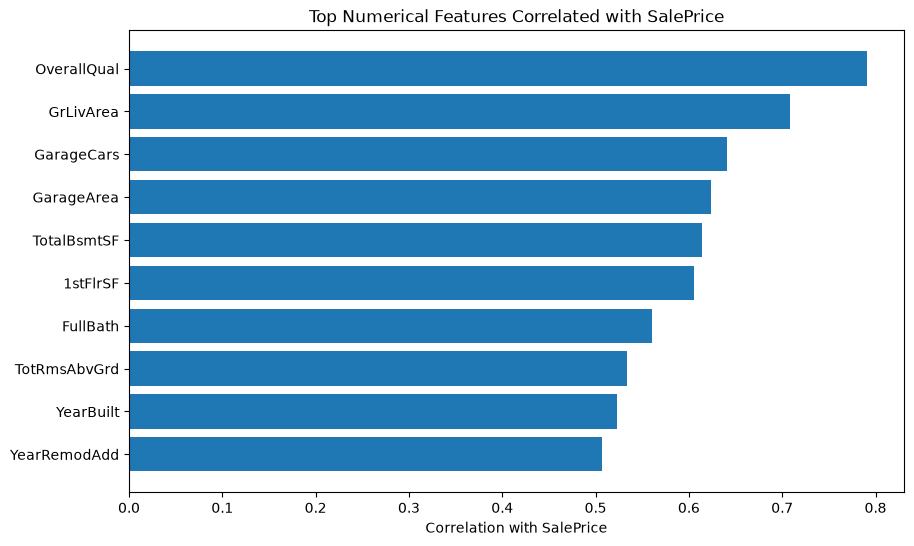

In [63]:
top_features = correlations.drop("SalePrice").head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.xlabel("Correlation with SalePrice")
plt.title("Top Numerical Features Correlated with SalePrice")

plt.savefig(
    "../figures/top_correlations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

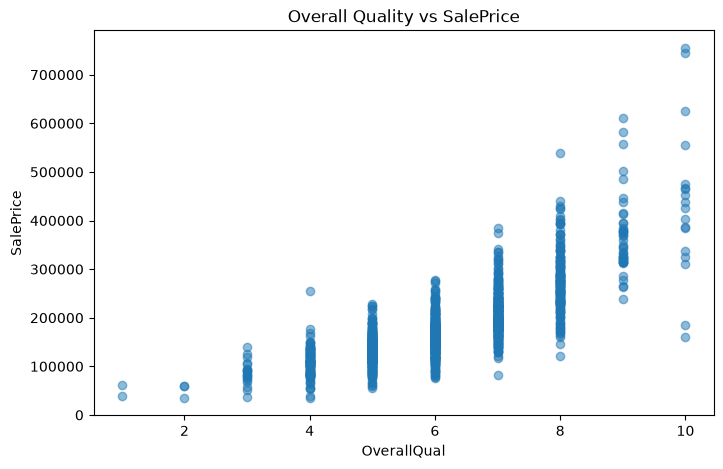

In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["OverallQual"], clean_df["SalePrice"], alpha=0.5)
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Overall Quality vs SalePrice")
plt.show()

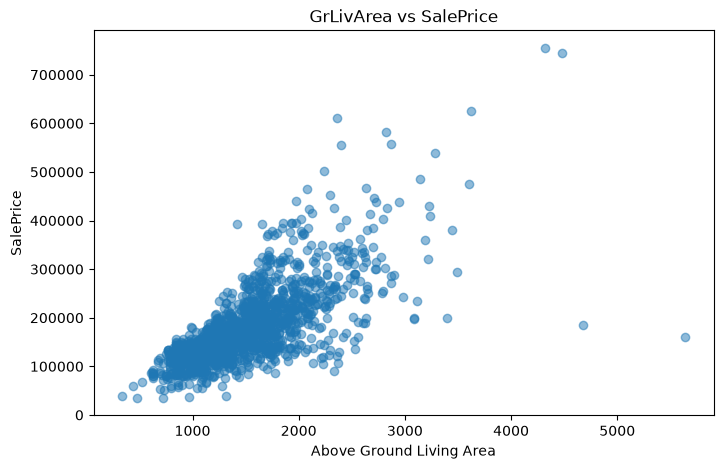

In [44]:
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["GrLivArea"], clean_df["SalePrice"], alpha=0.5)
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()

### Correlation Findings

Among the numerical features, `OverallQual` shows the strongest correlation
with `SalePrice` (approximately 0.79), followed by `GrLivArea` (approximately
0.71).

Garage capacity, garage area, basement area, and first-floor area also show
moderately strong positive relationships with house prices.

These relationships suggest that overall property quality and usable living
space are important predictors of sale price.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [46]:
X = clean_df.drop(columns=["SalePrice"])
y = clean_df["SalePrice"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (1168, 80)
Validation set: (292, 80)


In [47]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["str", "object"]).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 37
Categorical features: 43


In [48]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [49]:
models = {
    "Dummy Baseline": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [50]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_valid)

    rmse = root_mean_squared_error(y_valid, predictions)
    mae = mean_absolute_error(y_valid, predictions)
    r2 = r2_score(y_valid, predictions)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")

results_df

,Model,RMSE,MAE,R2
3,Gradient Boosting,27790.020491,17164.860489,0.899315
2,Random Forest,29023.695652,17494.975502,0.890177
1,Ridge Regression,29720.634331,19101.405737,0.884840
0,Dummy Baseline,87619.034506,62575.926452,-0.000882


### Initial Model Comparison

The Gradient Boosting model achieved the best validation performance among
the tested models.

- RMSE: approximately $27,790
- MAE: approximately $17,165
- R²: approximately 0.899

Random Forest and Ridge Regression also performed substantially better than
the Dummy baseline.

The Dummy baseline produced an RMSE of approximately $87,619, showing that
the machine learning models provide a large improvement over simply predicting
the average house price.

Based on the initial validation results, Gradient Boosting is the leading
candidate for the final model.

In [51]:
from sklearn.model_selection import cross_val_score

best_pipeline = trained_models["Gradient Boosting"]

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse = -cv_scores

print("Fold RMSE:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())
print("Std CV RMSE:", cv_rmse.std())

Fold RMSE: [23534.66421654 32806.16651018 27905.73560421 22541.65014612
 27567.98442384]
Mean CV RMSE: 26871.240180176137
Std CV RMSE: 3651.220970855307


### Cross-Validation Results

To verify that the Gradient Boosting result was not caused by a favorable
single train-validation split, I evaluated the model using 5-fold
cross-validation.

The mean cross-validation RMSE was approximately $26,871, with a standard
deviation of approximately $3,651.

This result is similar to the original validation RMSE of approximately
$27,790, providing additional evidence that the model generalizes reasonably
well across different subsets of the training data.

Although performance varies between folds, Gradient Boosting remains the
strongest candidate for the final model.

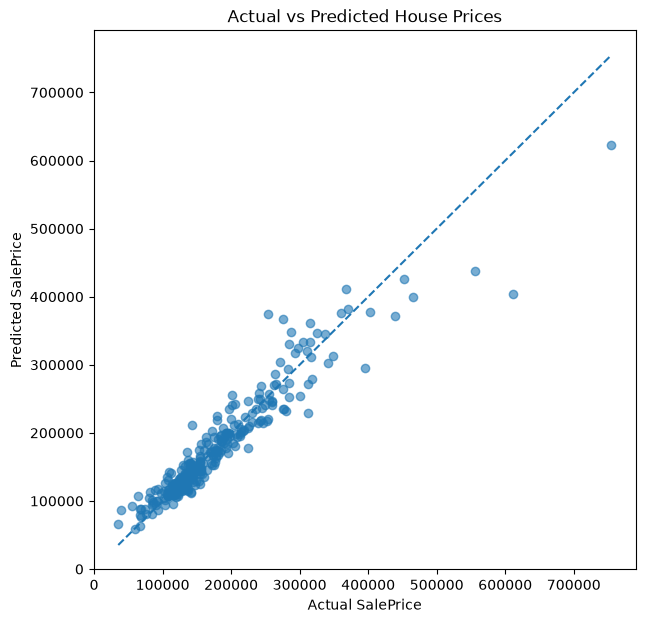

In [64]:
final_model = trained_models["Gradient Boosting"]

final_predictions = final_model.predict(X_valid)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_valid,
    final_predictions,
    alpha=0.6
)

min_price = min(y_valid.min(), final_predictions.min())
max_price = max(y_valid.max(), final_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "../figures/actual_vs_predicted.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [53]:
error_df = pd.DataFrame({
    "Actual": y_valid,
    "Predicted": final_predictions
})

error_df["Error"] = error_df["Predicted"] - error_df["Actual"]
error_df["AbsoluteError"] = error_df["Error"].abs()

error_df.sort_values(
    "AbsoluteError",
    ascending=False
).head(10)

,Actual,Predicted,Error,AbsoluteError
898,611657,403266.454402,-208390.545598,208390.545598
691,755000,623130.716719,-131869.283281,131869.283281
581,253293,374979.540508,121686.540508,121686.540508
1046,556581,437505.100851,-119075.899149,119075.899149
774,395000,295771.766238,-99228.233762,99228.233762
261,276000,366728.240186,90728.240186,90728.240186
218,311500,228829.839055,-82670.160945,82670.160945
588,143000,211655.338051,68655.338051,68655.338051
58,438780,371406.377276,-67373.622724,67373.622724
1243,465000,399233.076708,-65766.923292,65766.923292


In [54]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_values = final_model.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
4,num__OverallQual,0.501739
16,num__GrLivArea,0.153685
26,num__GarageCars,0.042024
12,num__TotalBsmtSF,0.035139
9,num__BsmtFinSF1,0.033492
13,num__1stFlrSF,0.029451
14,num__2ndFlrSF,0.027656
3,num__LotArea,0.018394
6,num__YearBuilt,0.017775
183,cat__BsmtQual_Ex,0.015935


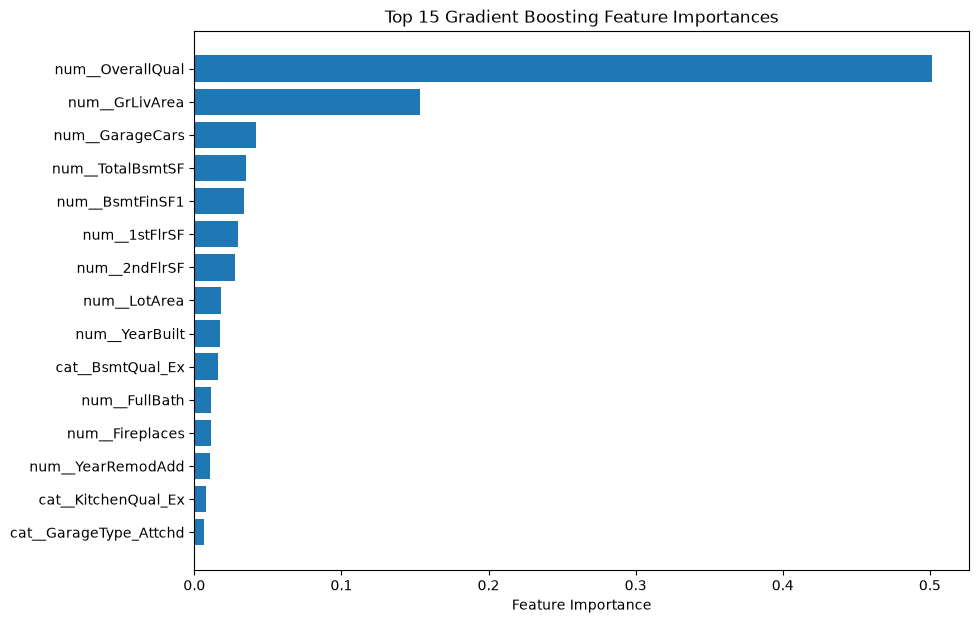

In [65]:
top_importance = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importance["Feature"][::-1],
    top_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Gradient Boosting Feature Importances")

plt.savefig(
    "../figures/feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Prediction Error Analysis

The Gradient Boosting model performs well overall, but the largest errors show
that some individual properties are difficult to predict accurately.

Several of the largest errors occur for high-priced homes. For example,
a house sold for approximately $611,657 was predicted at about $403,266,
resulting in an underprediction of more than $200,000.

The model also produced some large overpredictions for mid-priced homes.

These results suggest that unusual or expensive properties may have
characteristics that are not fully captured by the model. This is also
consistent with the right-skewed `SalePrice` distribution observed earlier.

Therefore, although the overall RMSE and R² are strong, individual prediction
errors can still be substantial, especially for less typical properties.

In [56]:
feature_importance_df.head(15)

,Feature,Importance
4,num__OverallQual,0.501739
16,num__GrLivArea,0.153685
26,num__GarageCars,0.042024
12,num__TotalBsmtSF,0.035139
9,num__BsmtFinSF1,0.033492
13,num__1stFlrSF,0.029451
14,num__2ndFlrSF,0.027656
3,num__LotArea,0.018394
6,num__YearBuilt,0.017775
183,cat__BsmtQual_Ex,0.015935


### Feature Importance Interpretation

The Gradient Boosting model indicates that `OverallQual` is the most
important predictive feature by a large margin, accounting for approximately
50% of the model's total feature importance.

`GrLivArea` is the second most important feature, followed by garage capacity,
basement area, finished basement area, and first-floor area.

This result is consistent with the earlier correlation analysis, where
`OverallQual` and `GrLivArea` also showed the strongest relationships with
`SalePrice`.

The model therefore suggests that the overall quality of a house and the
amount of usable living space are two of the strongest predictors of sale
price in this dataset.

Feature importance reflects how the model uses the variables for prediction
and should not be interpreted as proving a causal relationship.

## Final Conclusion

This project used an AI-assisted, end-to-end data science workflow to predict
residential house prices using the Kaggle House Prices dataset.

The analysis included data understanding, missing-value investigation,
exploratory data analysis, preprocessing, model comparison, cross-validation,
prediction-error analysis, and model interpretation.

Four regression approaches were evaluated:

- Dummy Regressor
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Gradient Boosting achieved the strongest validation performance:

- RMSE: approximately $27,790
- MAE: approximately $17,165
- R²: approximately 0.899

The 5-fold cross-validation mean RMSE was approximately $26,871, providing
additional evidence that the model performs consistently across different
subsets of the data.

The most important predictive features were `OverallQual` and `GrLivArea`,
suggesting that overall property quality and living space play major roles
in house-price prediction.

The error analysis also showed that some unusual and high-priced properties
remain difficult to predict accurately. Therefore, strong overall metrics do
not guarantee accurate predictions for every individual property.

AI tools assisted with planning, coding, debugging, and interpretation, but
the outputs were executed, inspected, and interpreted before being included
in the final project.

In [57]:
results_df.to_csv(
    "../results/model_comparison.csv",
    index=False
)

In [58]:
cv_results_df = pd.DataFrame({
    "Fold": range(1, len(cv_rmse) + 1),
    "RMSE": cv_rmse
})

cv_results_df.to_csv(
    "../results/cross_validation_rmse.csv",
    index=False
)

In [59]:
error_df.sort_values(
    "AbsoluteError",
    ascending=False
).to_csv(
    "../results/prediction_errors.csv",
    index=True
)

In [60]:
feature_importance_df.to_csv(
    "../results/feature_importance.csv",
    index=False
)

In [69]:
plt.savefig(
    "../figures/feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>